In [ ]:
# Clone MedSAM2 repository
!git clone https://github.com/bowang-lab/MedSAM2.git

# Install MedSAM2 and download checkpoints
%cd /content/MedSAM2
!pip install -e ".[dev]"
!bash download.sh
%cd /content

# Install HuggingFace Hub for dataset downloading
!pip install -U huggingface_hub

[WinError 3] The system cannot find the path specified: '/content/MedSAM2'
c:\Users\manol\Desktop\Pytorch_tutorial\SAM\MedSAM2 inference on LLD-MMRI\MedSSAM2_inference_CT_Deepleison


Cloning into 'MedSAM2'...
C:\Users\manol\AppData\Roaming\Python\Python310\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


^C
[WinError 2] The system cannot find the file specified: '/content'
c:\Users\manol\Desktop\Pytorch_tutorial\SAM\MedSAM2 inference on LLD-MMRI\MedSSAM2_inference_CT_Deepleison


'bash' is not recognized as an internal or external command,
operable program or batch file.


Obtaining file:///C:/Users/manol/Desktop/Pytorch_tutorial/SAM/MedSAM2%20inference%20on%20LLD-MMRI/MedSSAM2_inference_CT_Deepleison



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: file:///C:/Users/manol/Desktop/Pytorch_tutorial/SAM/MedSAM2%20inference%20on%20LLD-MMRI/MedSSAM2_inference_CT_Deepleison does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [ ]:
# # load libraries and define necessary functions
# from glob import glob
# from tqdm import tqdm
# import os
# from os.path import join, basename
# import re
# import matplotlib.pyplot as plt
# from collections import OrderedDict
# import pandas as pd
# import numpy as np
# import argparse

# from PIL import Image
# import SimpleITK as sitk
# import torch
# import torch.multiprocessing as mp
# from sam2.build_sam import build_sam2_video_predictor_npz
# import SimpleITK as sitk
# from skimage import measure, morphology

# torch.set_float32_matmul_precision('high')
# torch.manual_seed(2024)
# torch.cuda.manual_seed(2024)
# np.random.seed(2024)


# def getLargestCC(segmentation):
#     labels = measure.label(segmentation)
#     largestCC = labels == np.argmax(np.bincount(labels.flat)[1:])+1
#     return largestCC

# def show_mask(mask, ax, mask_color=None, alpha=0.5):
#     """
#     show mask on the image

#     Parameters
#     ----------
#     mask : numpy.ndarray
#         mask of the image
#     ax : matplotlib.axes.Axes
#         axes to plot the mask
#     mask_color : numpy.ndarray
#         color of the mask
#     alpha : float
#         transparency of the mask
#     """
#     if mask_color is not None:
#         color = np.concatenate([mask_color, np.array([alpha])], axis=0)
#     else:
#         color = np.array([251/255, 252/255, 30/255, alpha])
#     h, w = mask.shape[-2:]
#     mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
#     ax.imshow(mask_image)


# def show_box(box, ax, edgecolor='blue'):
#     """
#     show bounding box on the image

#     Parameters
#     ----------
#     box : numpy.ndarray
#         bounding box coordinates in the original image
#     ax : matplotlib.axes.Axes
#         axes to plot the bounding box
#     edgecolor : str
#         color of the bounding box
#     """
#     x0, y0 = box[0], box[1]
#     w, h = box[2] - box[0], box[3] - box[1]
#     ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor=edgecolor, facecolor=(0,0,0,0), lw=2))
import os
from glob import glob
from os.path import join, basename
import re
import matplotlib.pyplot as plt
from collections import OrderedDict
import pandas as pd
import numpy as np
from PIL import Image
import SimpleITK as sitk
import torch
from skimage import measure

import sys
sys.path.append('/content/MedSAM2')
from sam2.build_sam import build_sam2_video_predictor_npz

# Fix seeds for reproducibility
torch.set_float32_matmul_precision('high')
torch.manual_seed(2024)
torch.cuda.manual_seed(2024)
np.random.seed(2024)

def getLargestCC(segmentation):
    labels = measure.label(segmentation)
    if labels.max() == 0:
        return segmentation
    largestCC = labels == np.argmax(np.bincount(labels.flat)[1:])+1
    return largestCC

def show_mask(mask, ax, mask_color=None, alpha=0.5):
    """Overlays the binary mask on the given matplotlib axis"""
    if mask_color is not None:
        color = np.concatenate([mask_color, np.array([alpha])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, alpha])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def calculate_dice(pred, target):
    """Calculate 3D Dice Similarity Coefficient between two binary arrays"""
    pred_bool = np.asarray(pred).astype(bool)
    target_bool = np.asarray(target).astype(bool)
    intersection = np.logical_and(pred_bool, target_bool).sum()

    if pred_bool.sum() == 0 and target_bool.sum() == 0:
        return 1.0 # Both masks are empty, perfect match

    return 2.0 * intersection / (pred_bool.sum() + target_bool.sum())

def resize_grayscale_to_rgb_and_resize(array, image_size):
    """Converts 3D NIfTI numpy array to pseudo-RGB for MedSAM2"""
    d, h, w = array.shape
    resized_array = np.zeros((d, 3, image_size, image_size))
    for i in range(d):
        img_pil = Image.fromarray(array[i].astype(np.uint8))
        img_rgb = img_pil.convert("RGB")
        img_resized = img_rgb.resize((image_size, image_size))
        img_array = np.array(img_resized).transpose(2, 0, 1)
        resized_array[i] = img_array
    return resized_array

Please specify the following:

- `checkpoint`: model checkpoint  
- `imgs_path`: path to the 3D volume in `nii.gz` format  
- `model_cfg`: model config path  
- `pred_save_dir`: path to save the inference results  
- `path_DL_info`: path to the CT lesion key slices info  

In [ ]:
# !pip install -U huggingface_hub

# # Download the dataset directly into your MedSAM2 folder
# !hf download \
#     wanglab/CT_DeepLesion-MedSAM2 \
#     --repo-type dataset \
#     --local-dir /content/MedSAM2/CT_DeepLesion
# Download images and metadata CSV
!hf download wanglab/CT_DeepLesion-MedSAM2 \
    --repo-type dataset \
    --local-dir /content/MedSAM2/CT_DeepLesion

# Explicitly download the Ground Truth labels folder
!hf download wanglab/CT_DeepLesion-MedSAM2 \
    --repo-type dataset \
    --include "labels/*" \
    --local-dir /content/MedSAM2/CT_DeepLesion

Number of files in the repo is unreliable. Using `list_repo_tree` to ensure all files are listed.
Fetching ... files: 2255it [04:18,  8.37it/s]
Fetching ... files: 4436it [08:34, 11.21it/s]
Fetching ... files: 4590it [08:53,  8.11it/s]
Fetching ... files: 5326it [10:14,  7.05it/s]
Fetching ... files: 6584it [12:36,  9.36it/s]
Fetching ... files: 6868it [13:07,  6.80it/s]
Fetching ... files: 8848it [16:51, 10.06it/s]
Fetching ... files: 8943it [17:02,  7.54it/s]
Fetching ... files: 9140it [17:18, 14.89it/s]
Fetching ... files: 9149it [17:18, 13.17it/s]
Fetching ... files: 9565it [17:51, 11.47it/s]
Fetching ... files: 9647it [17:57, 11.85it/s]
Fetching ... files: 9703it [18:01, 14.25it/s]
Fetching ... files: 9956it [18:20, 14.14it/s]
Fetching ... files: 10222it [18:40, 14.27it/s]
Fetching ... files: 10264it [18:44, 10.43it/s]
Fetching ... files: 10280it [18:45, 14.60it/s]No local file found. Retrying..
No local file found. Retrying..
HTTP Error 429 thrown while requesting HEAD https://hu

In [ ]:
!huggingface-cli download \
    wanglab/CT_DeepLesion-MedSAM2 \
    --repo-type dataset \
    --include "labels/*" \
    --local-dir /content/MedSAM2/CT_DeepLesion

In [ ]:
# import os
# import pandas as pd# Set paths to the model checkpoint, image directory, and dataset information of the bounding boxes
# checkpoint = '/content/MedSAM2/checkpoints/MedSAM2_latest.pt'
# imgs_path = '/content/MedSAM2/CT_DeepLesion/images'
# model_cfg = "configs/sam2.1_hiera_t512.yaml" # Changed to relative path for Hydra to find it correctly
# pred_save_dir = "./DeeLesion_results"
# os.makedirs("./DeeLesion_results/", exist_ok=True)
# path_DL_info = '/content/MedSAM2/CT_DeepLesion/DeepLesion_Dataset_Info.csv'
# DL_info = pd.read_csv(path_DL_info)
checkpoint = '/content/MedSAM2/checkpoints/MedSAM2_latest.pt'
imgs_path = '/content/MedSAM2/CT_DeepLesion/images'
labels_path = '/content/MedSAM2/CT_DeepLesion/labels'
model_cfg = "configs/sam2.1_hiera_t512.yaml"
pred_save_dir = "/content/DeeLesion_results"
path_DL_info = '/content/MedSAM2/CT_DeepLesion/DeepLesion_Dataset_Info.csv'

os.makedirs(pred_save_dir, exist_ok=True)
DL_info = pd.read_csv(path_DL_info)

# Initialize dictionary to keep track of results
seg_info = OrderedDict()
seg_info['nii_name'] = []
seg_info['key_slice_index'] = []
seg_info['DICOM_windows'] = []
seg_info['dice_score'] = []

# Move into MedSAM2 folder so the hydra config paths work, build model, then move back
%cd /content/MedSAM2
predictor = build_sam2_video_predictor_npz(model_cfg, checkpoint)
%cd /content

/content/MedSAM2


/content/MedSAM2/sam2/modeling/sam/transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


/content


For the purpose of the demo, we perform segmentation only on a single image in the `imgs_path`.

In [ ]:
# from collections import OrderedDict

# # Nii file name used for this demo
# nii_fname = sorted(os.listdir(imgs_path))[0]

# seg_info = OrderedDict()
# seg_info['nii_name'] = []
# seg_info['key_slice_index'] = []
# seg_info['DICOM_windows'] = []

In [ ]:
# import SimpleITK as sitk
# import re
# import glob
# import os
# from sam2.build_sam import build_sam2_video_predictor_npz
# from os.path import join
# import numpy as np
# import torch
# from PIL import Image

# def resize_grayscale_to_rgb_and_resize(array, image_size):
#     """
#     Resize a 3D grayscale NumPy array to an RGB image and then resize it.

#     Parameters:
#         array (np.ndarray): Input array of shape (d, h, w).
#         image_size (int): Desired size for the width and height.

#     Returns:
#         np.ndarray: Resized array of shape (d, 3, image_size, image_size).
#     """
#     d, h, w = array.shape
#     resized_array = np.zeros((d, 3, image_size, image_size))

#     for i in range(d):
#         img_pil = Image.fromarray(array[i].astype(np.uint8))
#         img_rgb = img_pil.convert("RGB")
#         img_resized = img_rgb.resize((image_size, image_size))
#         img_array = np.array(img_resized).transpose(2, 0, 1)  # (3, image_size, image_size)
#         resized_array[i] = img_array

#     return resized_array

# # initialized predictor
# predictor = build_sam2_video_predictor_npz(model_cfg, checkpoint)

# all_nii_files = sorted(glob.glob(join(imgs_path, '*.nii.gz')))
# print(f'Found {len(all_nii_files)} files to process in {imgs_path}')

# for nii_path in all_nii_files:
#     nii_fname = os.path.basename(nii_path)
#     print(f'Processing {nii_fname}')
#     try:
#         # get corresponding case info
#         range_suffix = re.findall(r'\d{3}-\d{3}', nii_fname)[0]
#         slice_range = range_suffix.split('-')
#         slice_range = [str(int(s)) for s in slice_range]
#         slice_range = ', '.join(slice_range)
#         nii_image = sitk.ReadImage(nii_path)
#         nii_image_data = sitk.GetArrayFromImage(nii_image)

#         case_name = re.findall(r'^(\d{6}_\d{2}_\d{2})', nii_fname)[0]
#         case_df = DL_info[
#             DL_info['File_name'].str.contains(case_name) &
#             DL_info['Slice_range'].str.contains(slice_range)
#         ].copy()

#         if case_df.empty:
#             print(f'Metadata not found for {nii_fname}. Skipping.')
#             continue

#         # initialize the segmentation
#         segs_3D = np.zeros(nii_image_data.shape, dtype=np.uint8)

#         row = case_df.iloc[0]
#         # get the key slice info and preprocess image
#         lower_bound, upper_bound = row['DICOM_windows'].split(',')
#         lower_bound, upper_bound = float(lower_bound), float(upper_bound)
#         nii_image_data_pre = np.clip(nii_image_data, lower_bound, upper_bound)
#         nii_image_data_pre = (nii_image_data_pre - np.min(nii_image_data_pre))/(np.max(nii_image_data_pre)-np.min(nii_image_data_pre))*255.0
#         nii_image_data_pre = np.uint8(nii_image_data_pre)
#         key_slice_idx = row['Key_slice_index']
#         key_slice_idx = int(key_slice_idx)
#         slice_range = row['Slice_range']
#         slice_idx_start, slice_idx_end = slice_range.split(',')
#         slice_idx_start, slice_idx_end = int(slice_idx_start), int(slice_idx_end)
#         bbox_coords = row['Bounding_boxes']
#         bbox_coords = bbox_coords.split(',')
#         bbox_coords = [int(float(coord)) for coord in bbox_coords]
#         #bbox_coords = expand_box(bbox_coords)
#         bbox = np.array(bbox_coords) # y_min, x_min, y_max, x_max
#         bbox = np.array([bbox[1], bbox[0], bbox[3], bbox[2]])

#         # get key slice image
#         key_slice_idx_offset = key_slice_idx - slice_idx_start
#         key_slice_img = nii_image_data_pre[key_slice_idx_offset, :,:]

#         img_3D_ori = nii_image_data_pre
#         print(img_3D_ori.shape)
#         assert np.max(img_3D_ori) < 256, f'input data should be in range [0, 255], but got {np.unique(img_3D_ori)}'

#         video_height = key_slice_img.shape[0]
#         video_width = key_slice_img.shape[1]
#         img_resized = resize_grayscale_to_rgb_and_resize(img_3D_ori, 512)
#         img_resized = img_resized / 255.0
#         img_resized = torch.from_numpy(img_resized).cuda()
#         img_mean=(0.485, 0.456, 0.406)
#         img_std=(0.229, 0.224, 0.225)
#         img_mean = torch.tensor(img_mean, dtype=torch.float32)[:, None, None].cuda()
#         img_std = torch.tensor(img_std, dtype=torch.float32)[:, None, None].cuda()
#         img_resized -= img_mean
#         img_resized /= img_std

#         with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
#             inference_state = predictor.init_state(img_resized, video_height, video_width)

#             _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
#                                                 inference_state=inference_state,
#                                                 frame_idx=key_slice_idx_offset,
#                                                 obj_id=1,
#                                                 box=bbox,
#                                                 )


#             for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
#                 segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1
#             predictor.reset_state(inference_state)

#             _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
#                                                 inference_state=inference_state,
#                                                 frame_idx=key_slice_idx_offset,
#                                                 obj_id=1,
#                                                 box=bbox,
#                                             )


#             for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state, reverse=True):
#                 segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1
#             predictor.reset_state(inference_state)
#         if np.max(segs_3D) > 0:
#             segs_3D = getLargestCC(segs_3D)
#             segs_3D = np.uint8(segs_3D)
#         sitk_image = sitk.GetImageFromArray(img_3D_ori)
#         sitk_image.CopyInformation(nii_image)
#         sitk_mask = sitk.GetImageFromArray(segs_3D)
#         sitk_mask.CopyInformation(nii_image)
#         # save single lesion
#         key_slice_idx = row['Key_slice_index']
#         save_seg_name = nii_fname.split('.nii.gz')[0] + f'_k{key_slice_idx}_mask.nii.gz'
#         sitk.WriteImage(sitk_image, os.path.join(pred_save_dir, nii_fname.replace('.nii.gz', '_img.nii.gz')))
#         sitk.WriteImage(sitk_mask, os.path.join(pred_save_dir, save_seg_name))
#         seg_info['nii_name'].append(save_seg_name)
#         seg_info['key_slice_index'].append(key_slice_idx)
#         seg_info['DICOM_windows'].append(row['DICOM_windows'])
#     except Exception as e:
#         print(f'Error processing {nii_fname}: {e}')

all_nii_files = sorted(glob(join(imgs_path, '*.nii.gz')))
print(f'Found {len(all_nii_files)} image files. Starting evaluation...\n')

for nii_path in all_nii_files:
    nii_fname = basename(nii_path)

    # 1. FILTER: Check if Ground Truth mask exists for this image
    gt_path = os.path.join(labels_path, nii_fname)
    if not os.path.exists(gt_path):
        continue # Skip images without ground truth to save compute time

    print(f'Processing: {nii_fname}')
    try:
        # Load GT Mask
        gt_image = sitk.ReadImage(gt_path)
        gt_data = sitk.GetArrayFromImage(gt_image)
        gt_data_binary = (gt_data > 0).astype(np.uint8)

        # Get corresponding case info
        range_suffix = re.findall(r'\d{3}-\d{3}', nii_fname)[0]
        slice_range = [str(int(s)) for s in range_suffix.split('-')]
        slice_range_str = ', '.join(slice_range)

        nii_image = sitk.ReadImage(nii_path)
        nii_image_data = sitk.GetArrayFromImage(nii_image)

        case_name = re.findall(r'^(\d{6}_\d{2}_\d{2})', nii_fname)[0]
        case_df = DL_info[
            DL_info['File_name'].str.contains(case_name) &
            DL_info['Slice_range'].str.contains(slice_range_str)
        ].copy()

        if case_df.empty:
            continue

        segs_3D = np.zeros(nii_image_data.shape, dtype=np.uint8)
        row = case_df.iloc[0]

        # Preprocess image
        lower_bound, upper_bound = map(float, row['DICOM_windows'].split(','))
        nii_image_data_pre = np.clip(nii_image_data, lower_bound, upper_bound)
        nii_image_data_pre = (nii_image_data_pre - np.min(nii_image_data_pre))/(np.max(nii_image_data_pre)-np.min(nii_image_data_pre))*255.0
        nii_image_data_pre = np.uint8(nii_image_data_pre)

        key_slice_idx = int(row['Key_slice_index'])
        slice_idx_start, slice_idx_end = map(int, row['Slice_range'].split(','))
        bbox_coords = [int(float(coord)) for coord in row['Bounding_boxes'].split(',')]
        bbox = np.array([bbox_coords[1], bbox_coords[0], bbox_coords[3], bbox_coords[2]])

        key_slice_idx_offset = key_slice_idx - slice_idx_start
        key_slice_img = nii_image_data_pre[key_slice_idx_offset, :,:]
        img_3D_ori = nii_image_data_pre

        video_height, video_width = key_slice_img.shape
        img_resized = resize_grayscale_to_rgb_and_resize(img_3D_ori, 512) / 255.0
        img_resized = torch.from_numpy(img_resized).cuda()

        img_mean = torch.tensor((0.485, 0.456, 0.406), dtype=torch.float32)[:, None, None].cuda()
        img_std = torch.tensor((0.229, 0.224, 0.225), dtype=torch.float32)[:, None, None].cuda()
        img_resized = (img_resized - img_mean) / img_std

        # INFERENCE
        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            inference_state = predictor.init_state(img_resized, video_height, video_width)

            _, _, out_mask_logits = predictor.add_new_points_or_box(
                                        inference_state=inference_state,
                                        frame_idx=key_slice_idx_offset,
                                        obj_id=1, box=bbox)

            for out_frame_idx, _, out_mask_logits in predictor.propagate_in_video(inference_state):
                segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1
            predictor.reset_state(inference_state)

            _, _, out_mask_logits = predictor.add_new_points_or_box(
                                        inference_state=inference_state,
                                        frame_idx=key_slice_idx_offset,
                                        obj_id=1, box=bbox)

            for out_frame_idx, _, out_mask_logits in predictor.propagate_in_video(inference_state, reverse=True):
                segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1
            predictor.reset_state(inference_state)

        if np.max(segs_3D) > 0:
            segs_3D = np.uint8(getLargestCC(segs_3D))

        # EVALUATION (Dice Score)
        dice_score = calculate_dice(segs_3D, gt_data_binary)
        print(f" -> Dice Score: {dice_score:.4f}")

        # VISUALIZATION (1x3 Subplot)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Slices for visualization
        img_2d = img_3D_ori[key_slice_idx_offset]
        gt_2d = gt_data_binary[key_slice_idx_offset]
        pred_2d = segs_3D[key_slice_idx_offset]

        # 1. Raw Input Image
        axes[0].imshow(img_2d, cmap='gray')
        axes[0].set_title('Input Image', fontsize=14)
        axes[0].axis('off')

        # 2. Input + Ground Truth Mask (Green)
        axes[1].imshow(img_2d, cmap='gray')
        show_mask(gt_2d, ax=axes[1], mask_color=np.array([0, 1, 0]))
        axes[1].set_title('Ground Truth (Green)', fontsize=14)
        axes[1].axis('off')

        # 3. Input + Prediction (Yellow)
        axes[2].imshow(img_2d, cmap='gray')
        show_mask(pred_2d, ax=axes[2], mask_color=np.array([251/255, 252/255, 30/255]))
        axes[2].set_title(f'Generated Mask (Yellow)\nDice Score: {dice_score:.4f}', fontsize=14)
        axes[2].axis('off')

        plt.tight_layout()
        vis_save_path = os.path.join(pred_save_dir, nii_fname.replace('.nii.gz', '_comparison.png'))
        plt.savefig(vis_save_path, bbox_inches='tight')
        plt.close(fig) # Close to prevent Colab from crashing due to too many open plots

        # TRACK RESULTS
        save_seg_name = nii_fname.replace('.nii.gz', f'_k{key_slice_idx}_mask.nii.gz')
        sitk_mask = sitk.GetImageFromArray(segs_3D)
        sitk_mask.CopyInformation(nii_image)
        sitk.WriteImage(sitk_mask, os.path.join(pred_save_dir, save_seg_name))

        seg_info['nii_name'].append(save_seg_name)
        seg_info['key_slice_index'].append(key_slice_idx)
        seg_info['DICOM_windows'].append(row['DICOM_windows'])
        seg_info['dice_score'].append(dice_score)

    except Exception as e:
        print(f' -> Error processing {nii_fname}: {e}')
        plt.close('all') # Failsafe


Found 3946 image files. Starting evaluation...

Processing: 000086_03_01_077-099.nii.gz
 -> Error processing 000086_03_01_077-099.nii.gz: Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/content/MedSAM2/CT_DeepLesion/images/000086_03_01_077-099.nii.gz"
Processing: 000086_04_01_073-097.nii.gz


/content/MedSAM2/sam2/sam2_video_predictor_npz.py:965: UserWarning: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 13/13 [00:00<00:00, 16.32it/s]


 -> Dice Score: 0.0000
Processing: 000086_05_01_074-097.nii.gz
 -> Error processing 000086_05_01_074-097.nii.gz: Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/content/MedSAM2/CT_DeepLesion/images/000086_05_01_074-097.nii.gz"
Processing: 000087_01_01_076-099.nii.gz
 -> Error processing 000087_01_01_076-099.nii.gz: Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/content/MedSAM2/CT_DeepLesion/images/000087_01_01_076-099.nii.gz"
Processing: 000089_10_01_030-062.nii.gz
 -> Error processing 000089_10_01_030-062.nii.gz: Exception thrown in SimpleITK ImageFileReader_Execute: /work/src/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/content/MedSAM2/CT_DeepLesion/images/000089_10_01_030-062.nii.gz"
Processing: 000093_01_01_052-067

/content/MedSAM2/sam2/sam2_video_predictor_npz.py:965: UserWarning: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 8/8 [00:00<00:00, 17.91it/s]


 -> Dice Score: 0.4215
Processing: 000093_03_01_049-065.nii.gz


...

 -> Dice Score: 0.0000
Processing: 000341_05_01_067-092.nii.gz


propagate in video: 100%|██████████| 14/14 [00:00<00:00, 15.23it/s]


 -> Dice Score: 0.9408
Processing: 000341_06_01_023-035.nii.gz


propagate in video: 100%|██████████| 7/7 [00:00<00:00, 16.17it/s]


 -> Dice Score: 0.9559
Processing: 000341_06_01_044-091.nii.gz


In [ ]:
# save the segmentation info to a csv file
seg_info_df = pd.DataFrame(seg_info)
seg_info_df.to_csv(join(pred_save_dir, 'tiny_seg_info202412.csv'), index=False)

# Optional: Realization of the segmentation
In the following, we show the image and the overlayed segmentation slices of 25 percentile, key slice, and 75 percentile

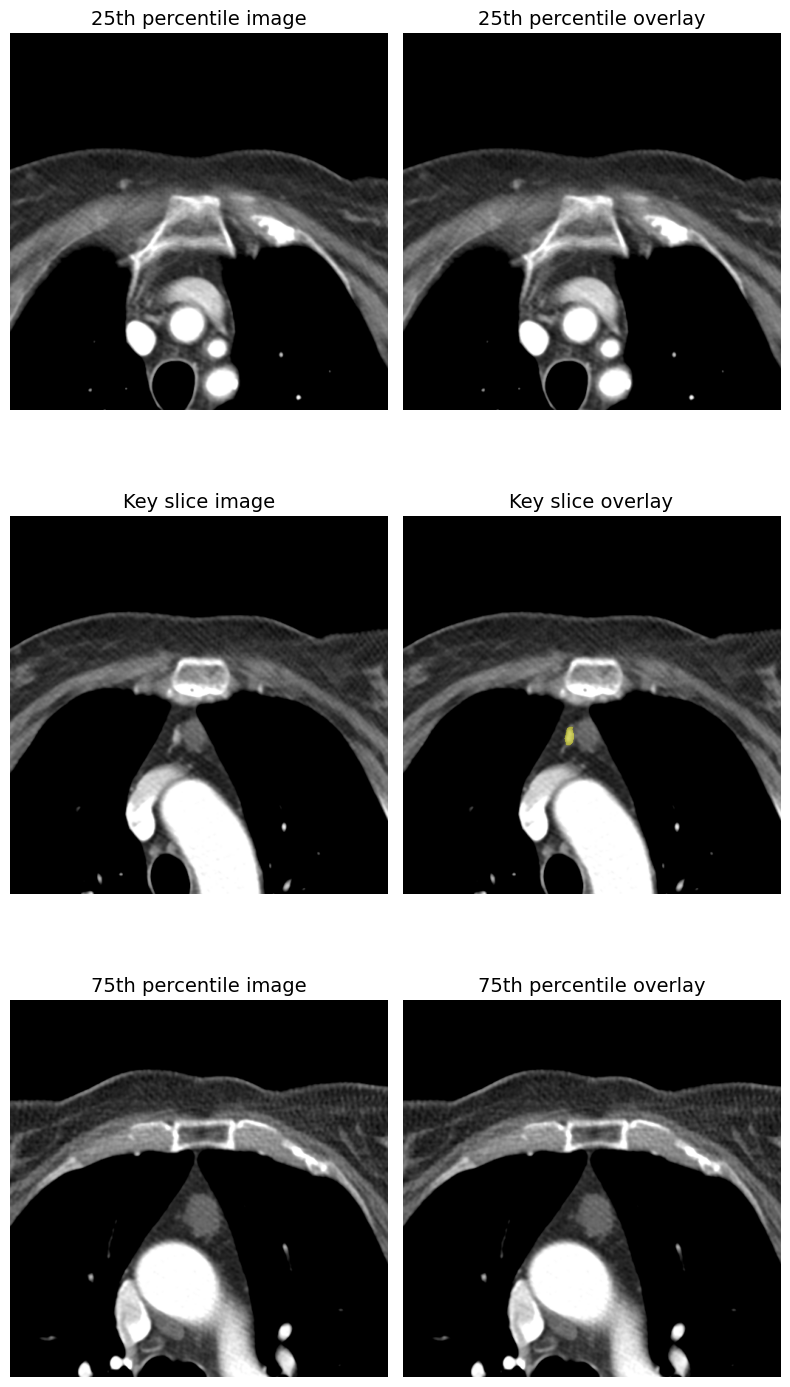

In [ ]:
# slice_indices = np.arange(0, slice_idx_end - slice_idx_start)
# slice_idx_25 = int(np.percentile(slice_indices, 25))
# slice_idx_75 = int(np.percentile(slice_indices, 75))
# percentile_slices = [slice_idx_25, key_slice_idx_offset, slice_idx_75]

# fig, axes = plt.subplots(3, 2, figsize=(8, 15))
# for ax in axes.flatten():
#     ax.axis('off')

# row_titles = ['25th percentile image', 'Key slice image', '75th percentile image']
# row_titles_masks = ['25th percentile overlay', 'Key slice overlay', '75th percentile overlay']

# for row_idx, slice_idx in enumerate(percentile_slices):
#     imgs_2D = img_3D_ori[slice_idx].T
#     imgs_2D = imgs_2D[:, :, None].repeat(3, axis=-1)
#     segs_2D = segs_3D[slice_idx].T

#     axes[row_idx, 0].imshow(imgs_2D, cmap='gray')
#     axes[row_idx, 1].imshow(imgs_2D, cmap='gray')
#     show_mask(segs_2D, ax=axes[row_idx, 1])

#     axes[row_idx, 0].set_title(row_titles[row_idx], fontsize=14)
#     axes[row_idx, 1].set_title(row_titles_masks[row_idx], fontsize=14)

# plt.tight_layout()

In [ ]:
# Save the tracking dataframe to CSV
seg_info_df = pd.DataFrame(seg_info)
results_csv_path = join(pred_save_dir, 'final_dice_results.csv')
seg_info_df.to_csv(results_csv_path, index=False)

# Display final summary
print("==================================================")
print(f"🎉 Evaluation Complete! Processed {len(seg_info_df)} valid GT masks.")
print(f"🏆 Mean Dice Score across dataset: {seg_info_df['dice_score'].mean():.4f}")
print(f"📁 Masks & Comparison PNGs saved to: {pred_save_dir}")
print("==================================================")

# Show the first 5 entries
display(seg_info_df.head())